In [1]:
import sys
!{sys.executable} -m pip install xgboost imbalanced-learn shap

Defaulting to user installation because normal site-packages is not writeable


In [2]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("✅ Librairies importées avec succès !")

✅ Librairies importées avec succès !


In [5]:
# Cellule 1 — Imports + Chargement + Renommage
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Chargement
df = pd.read_csv(r'C:\Users\merie\churn-prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Renommage colonnes
df = df.rename(columns={
    'tenure': 'mois_abonnement',
    'PhoneService': 'service_base',
    'MultipleLines': 'profils_partages',
    'InternetService': 'type_connexion',
    'OnlineSecurity': 'controle_parental',
    'OnlineBackup': 'sauvegarde_contenu',
    'DeviceProtection': 'protection_compte',
    'TechSupport': 'support_technique',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_films',
    'Contract': 'type_contrat',
    'PaperlessBilling': 'facturation_en_ligne',
    'PaymentMethod': 'mode_paiement',
    'MonthlyCharges': 'montant_mensuel',
    'TotalCharges': 'montant_total',
    'Churn': 'churn'
})

print(f" Dataset chargé et renommé !")
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

 Dataset chargé et renommé !
Dimensions : 7043 lignes x 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,mois_abonnement,service_base,profils_partages,type_connexion,controle_parental,sauvegarde_contenu,protection_compte,support_technique,streaming_tv,streaming_films,type_contrat,facturation_en_ligne,mode_paiement,montant_mensuel,montant_total,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Cellule 2 — Statistiques descriptives
print("=== INFOS GÉNÉRALES ===")
print(df.info())
print("\n=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== INFOS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7043 non-null   object 
 1   gender                7043 non-null   object 
 2   SeniorCitizen         7043 non-null   int64  
 3   Partner               7043 non-null   object 
 4   Dependents            7043 non-null   object 
 5   mois_abonnement       7043 non-null   int64  
 6   service_base          7043 non-null   object 
 7   profils_partages      7043 non-null   object 
 8   type_connexion        7043 non-null   object 
 9   controle_parental     7043 non-null   object 
 10  sauvegarde_contenu    7043 non-null   object 
 11  protection_compte     7043 non-null   object 
 12  support_technique     7043 non-null   object 
 13  streaming_tv          7043 non-null   object 
 14  streaming_films       7043 non-null   object 
 1

,SeniorCitizen,mois_abonnement,montant_mensuel
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
## 🔍 explication Cellule 3 — Correction des types & Valeurs manquantes

### Pourquoi cette étape ?
Lors de l'exploration initiale (`df.info()`), nous avons détecté une anomalie :
- La colonne `montant_total` est de type **object** (texte) au lieu de **float** (nombre).
- Cela est dû à des **espaces vides** dans le CSV original pour les clients
avec 0 mois d'ancienneté (nouveaux abonnés sans charges totales).

### Ce qu'on fait :
1. **`pd.to_numeric(..., errors='coerce')`** — convertit la colonne en float,
   les valeurs non convertibles deviennent **NaN**
2. **`isnull().sum()`** — compte les valeurs manquantes dans toutes les colonnes
   pour confirmer le nombre de lignes affectées

### Impact métier :
Ces 11 clients sont des **nouveaux abonnés** (mois_abonnement = 0).
Leur montant_total sera imputé à **0** lors de la phase de préparation des données.

In [8]:
# Cellule 3 — Correction montant_total + valeurs manquantes
# Convertir montant_total en numérique
df['montant_total'] = pd.to_numeric(df['montant_total'], errors='coerce')

# Vérifier les valeurs manquantes
print("=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\n Lignes avec montant_total manquant : {df['montant_total'].isnull().sum()}")
print(f" Nouveau type de montant_total : {df['montant_total'].dtype}")

=== VALEURS MANQUANTES ===
montant_total    11
dtype: int64

 Lignes avec montant_total manquant : 11
 Nouveau type de montant_total : float64


In [ ]:
## explication Cellule 4 — Distribution de la variable cible (Churn)

### Pourquoi cette étape ?
Comprendre le déséquilibre des classes est crucial avant la modélisation.
Un fort déséquilibre (ex: 90%/10%) peut biaiser le modèle vers la classe majoritaire.

### Ce qu'on fait :
- Calculer le ratio Churn / Non-Churn
- Visualiser la distribution avec un graphique

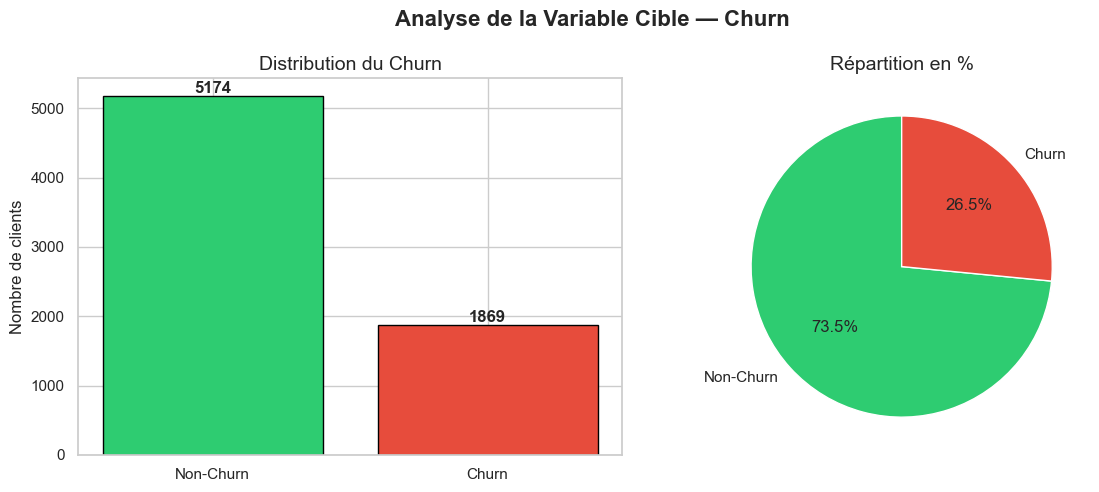


 Non-Churn : 5174 (73.5%)
 Churn : 1869 (26.5%)

 Déséquilibre détecté → SMOTE sera appliqué lors du preprocessing !


In [9]:
# Cellule 4 — Distribution du Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Comptage
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

# Graphique 1 — Barplot
axes[0].bar(['Non-Churn', 'Churn'], churn_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribution du Churn', fontsize=14)
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Graphique 2 — Pie chart
axes[1].pie(churn_counts.values, labels=['Non-Churn', 'Churn'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition en %', fontsize=14)

plt.suptitle('Analyse de la Variable Cible — Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\merie\churn-prediction\outputs\churn_distribution.png', dpi=150)
plt.show()

print(f"\n Non-Churn : {churn_counts['No']} ({churn_pct['No']:.1f}%)")
print(f" Churn : {churn_counts['Yes']} ({churn_pct['Yes']:.1f}%)")
print(f"\n Déséquilibre détecté → SMOTE sera appliqué lors du preprocessing !")

In [ ]:
## Interpretation — Distribution du Churn

### Observations :
- 73.5% des abonnés ne churned pas (classe majoritaire)
- 26.5% des abonnés ont churné (classe minoritaire)
- Le déséquilibre est modéré mais significatif

### Implications métier :
- Un modèle naif qui prédit toujours "Non-Churn" aurait 73.5% d'accuracy
  mais serait inutile pour détecter les churners
- Ce déséquilibre justifie l'utilisation de SMOTE en phase de preprocessing
- La métrique principale sera AUC-ROC et non l'accuracy

### Conclusion :
Le taux de churn de 26.5% est élevé pour une plateforme de streaming,
ce qui confirme l'urgence de mettre en place un système de prédiction.

In [ ]:
## explication Cellule 5 — Heatmap des corrélations

### Pourquoi cette étape ?
La heatmap permet d'identifier les relations linéaires entre variables numériques.
Elle aide à détecter la multicolinéarité et les variables les plus liées au churn.

### Ce qu'on fait :
- Encoder temporairement le churn en binaire (Yes=1, No=0)
- Calculer la matrice de corrélation
- Visualiser avec une heatmap annotée

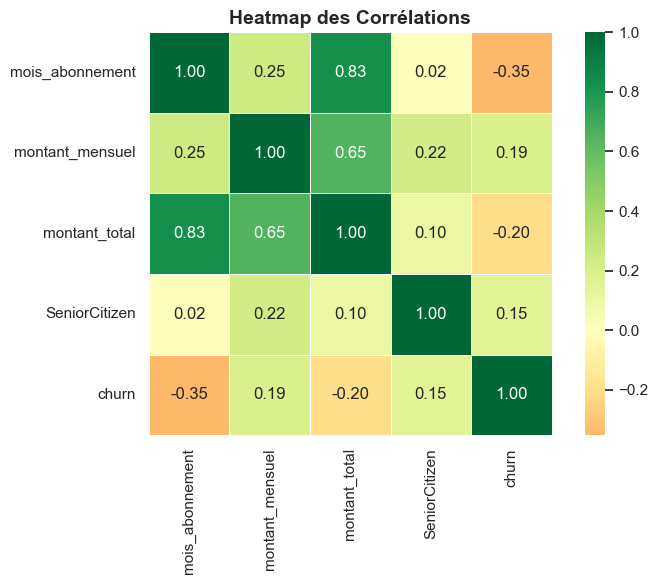

In [10]:
# Cellule 5 — Heatmap des corrélations
df_corr = df[['mois_abonnement', 'montant_mensuel', 'montant_total', 
              'SeniorCitizen', 'churn']].copy()
df_corr['churn'] = df_corr['churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Heatmap des Corrélations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\merie\churn-prediction\outputs\heatmap_correlations.png', dpi=150)
plt.show()

In [ ]:
## Interpretation — Heatmap des Corrélations

### Observations :

1. mois_abonnement vs churn (-0.35) :
   - Correlation negative moderee
   - Plus un client est abonne depuis longtemps, moins il a tendance a churner
   - Les nouveaux abonnes sont les plus a risque

2. montant_mensuel vs churn (+0.19) :
   - Correlation positive faible
   - Les clients avec des montants eleves churent legerement plus
   - Possiblement lies a des plans premium insatisfaisants

3. montant_total vs churn (-0.20) :
   - Correlation negative faible
   - Logique car montant_total est lie a l'anciennete

4. mois_abonnement vs montant_total (+0.83) :
   - Forte multicolinearite attendue
   - Ces deux variables portent une information similaire

### Conclusions metier :
- La variable la plus predictive du churn est mois_abonnement
- Les clients recents et a montant mensuel eleve sont les plus a risque
- Pas de multicolinearite problematique avec le churn

In [ ]:
## Cellule 6 — Distribution du Churn par variables catégorielles

### Pourquoi cette étape ?
Analyser comment le churn se répartit selon les variables catégorielles
permet d'identifier les segments les plus à risque.

### Ce qu'on fait :
- Visualiser le taux de churn par type de contrat
- Visualiser le taux de churn par mode de paiement
- Visualiser le taux de churn par type de connexion

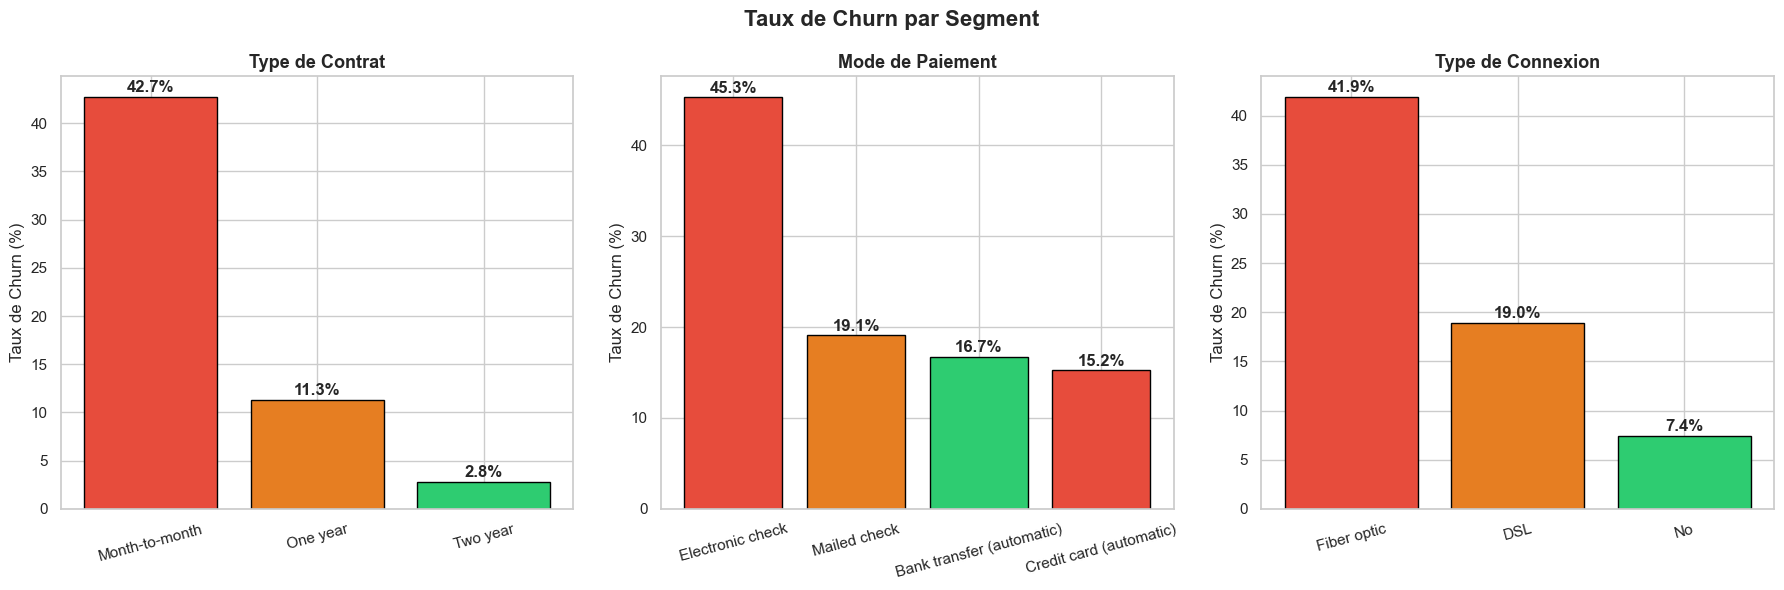

In [11]:
# Cellule 6 — Distribution du Churn par variables catégorielles
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

variables = ['type_contrat', 'mode_paiement', 'type_connexion']
titres = ['Type de Contrat', 'Mode de Paiement', 'Type de Connexion']

for i, (var, titre) in enumerate(zip(variables, titres)):
    churn_rate = df.groupby(var)['churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [var, 'taux_churn']
    churn_rate = churn_rate.sort_values('taux_churn', ascending=False)
    
    bars = axes[i].bar(churn_rate[var], churn_rate['taux_churn'],
                       color=['#e74c3c', '#e67e22', '#2ecc71'],
                       edgecolor='black')
    axes[i].set_title(titre, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Taux de Churn (%)')
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, churn_rate['taux_churn']):
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                     bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Taux de Churn par Segment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\merie\churn-prediction\outputs\churn_par_segment.png', dpi=150)
plt.show()

In [ ]:
## Interpretation — Taux de Churn par Segment

### 1. Type de Contrat :
- Month-to-month : 42.7% de churn — segment le plus a risque
- One year : 11.3% de churn — risque modere
- Two year : 2.8% de churn — segment le plus fidele
- Conclusion : Les contrats courts sont un facteur majeur de churn.
  L'equipe marketing devrait inciter les clients month-to-month
  a migrer vers des contrats annuels.

### 2. Mode de Paiement :
- Electronic check : 45.3% — taux alarmant
- Mailed check : 19.1% — risque modere
- Bank transfer : 16.7% — risque faible
- Credit card : 15.2% — risque le plus faible
- Conclusion : Les clients payant par cheque electronique
  sont significativement plus susceptibles de churner.

### 3. Type de Connexion :
- Fiber optic : 41.9% — taux tres eleve
- DSL : 19.0% — risque modere
- No internet : 7.4% — risque tres faible
- Conclusion : Les clients Fiber optic churent massivement,
  possiblement dus a une insatisfaction qualite/prix.

### Conclusion generale :
Le profil type du churner est : contrat month-to-month +
paiement par electronic check + connexion fiber optic.
Ce segment doit etre la priorite des actions de retention.

In [ ]:
## Cellule 7 — Distribution de l'anciennete des abonnes

### Pourquoi cette etape ?
Comprendre la distribution de l'anciennete des abonnes permet
d'identifier les periodes critiques de churn dans le cycle de vie client.

### Ce qu'on fait :
- Visualiser la distribution de mois_abonnement
- Comparer la distribution entre churners et non-churners

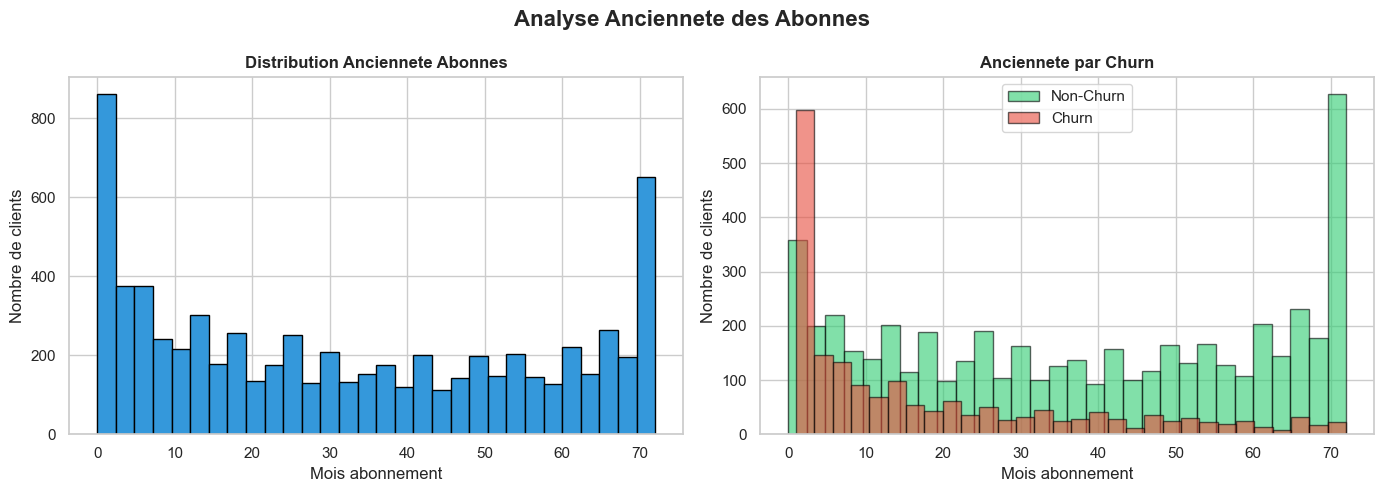

In [12]:
# Cellule 7 — Distribution mois_abonnement par churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
axes[0].hist(df['mois_abonnement'], bins=30, color='#3498db', edgecolor='black')
axes[0].set_title('Distribution Anciennete Abonnes', fontweight='bold')
axes[0].set_xlabel('Mois abonnement')
axes[0].set_ylabel('Nombre de clients')

# Par churn
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    subset = df[df['churn'] == label]['mois_abonnement']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, 
                 edgecolor='black', label=label)
axes[1].set_title('Anciennete par Churn', fontweight='bold')
axes[1].set_xlabel('Mois abonnement')
axes[1].set_ylabel('Nombre de clients')
axes[1].legend(['Non-Churn', 'Churn'])

plt.suptitle('Analyse Anciennete des Abonnes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\merie\churn-prediction\outputs\distribution_anciennete.png', dpi=150)
plt.show()